# KardioSense vs ISIBrno — Step 2: Shared Evaluation Harness

**Inputs (from Step 1 + NB02):**
- `benchmark/preds_isibrno_fold10.npy` — ISIBrno probabilities on fold 10 (499 records × 5)
- `benchmark/labels_test_fold10.npy` — ground truth labels, same fold
- `checkpoints/kardiosense_ecg_best_mi.pt` — KardioSense trained weights
- PTB-XL preprocessed cache — to re-run KardioSense inference fresh

**What this notebook produces:**
1. KardioSense test predictions (re-run from checkpoint to ensure parity)
2. Optimal thresholds for both models (tuned on fold 9 validation set)
3. Full metric table: AUC, AP, Precision, Recall, F1, Brier — per class, per model
4. ROC and PR curve overlays — both models on one plot per class
5. Confusion matrix comparison side-by-side
6. MI score distribution comparison
7. Saved results: `benchmark/results_step2.json` — machine-readable for Step 4 reports


## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = os.environ.get('KARDIOSENSE_BASE_DIR', '/content/drive/MyDrive/KardioSenseAI')
DATA_DIR = f'{BASE_DIR}/datasets'
PTBXL_DIR = f'{DATA_DIR}/ptb-xl'
CKPT_DIR = f'{BASE_DIR}/checkpoints'
LOG_DIR = f'{BASE_DIR}/logs'
BENCH_DIR = f'{BASE_DIR}/benchmark'

# ── Verify all required inputs exist ──────────────────────────────────────
required = {
 'PTB-XL cache' : f'{DATA_DIR}/ptbxl_preprocessed_500hz.npz',
 'KardioSense checkpoint': f'{CKPT_DIR}/kardiosense_ecg_best_mi.pt',
 'ISIBrno predictions' : f'{BENCH_DIR}/preds_isibrno_fold10.npy',
 'Ground truth labels' : f'{BENCH_DIR}/labels_test_fold10.npy',
}
print('Checking required files:')
all_ok = True
for name, path in required.items():
 exists = os.path.exists(path)
 size = f'{os.path.getsize(path)/1e6:.1f} MB' if exists else '—'
 status = '' if exists else ' MISSING'
 print(f' {status} {name:<28} {size}')
 if not exists: all_ok = False

assert all_ok, 'Run NB02 (Enhanced Lead-Agnostic) and Step 1 first.'
print('\nAll inputs present. Ready.')


Mounted at /content/drive
Checking required files:
  ✅  PTB-XL cache                  932.9 MB
  ✅  KardioSense checkpoint        36.5 MB
  ✅  ISIBrno predictions           0.0 MB
  ✅  Ground truth labels           0.0 MB

All inputs present. Ready.


In [2]:
!pip install -q seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
 roc_auc_score, average_precision_score, roc_curve,
 precision_recall_curve, confusion_matrix, f1_score
)
from scipy.optimize import minimize_scalar
import json, time, warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LABEL_NAMES = ['NORM', 'MI', 'AFIB', 'STTC', 'CD']
COLORS = {'NORM':'#06D6A0','MI':'#E63946','AFIB':'#00B4D8','STTC':'#FFB703','CD':'#A8DADC'}

# KardioSense 6-lead config — must match NB02
ALL_LEADS = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
SIX_LEAD_INDICES = [0, 1, 2, 5, 7, 9] # I, II, III, aVF, V2, V4
SIX_LEAD_NAMES = [ALL_LEADS[i] for i in SIX_LEAD_INDICES]
N_SAMPLES = 5000
FS = 500

print(f'Device : {DEVICE}')
print(f'Labels : {LABEL_NAMES}')
print(f'6-lead config: {SIX_LEAD_NAMES}')


Device : cuda
Labels : ['NORM', 'MI', 'AFIB', 'STTC', 'CD']
6-lead config: ['I', 'II', 'III', 'aVF', 'V2', 'V4']


## 1. Load Cache, Ground Truth & ISIBrno Predictions

In [3]:
# ── PTB-XL cache ───────────────────────────────────────────────────────────
print('Loading PTB-XL cache...')
t0 = time.time()
cache = np.load(f'{DATA_DIR}/ptbxl_preprocessed_500hz.npz')
X = cache['X'] # (N, 5000, 12)
Y = cache['Y'] # (N, 5)
ecg_ids = cache['ecg_ids']
print(f' Cache: {X.shape} [{time.time()-t0:.1f}s]')

# ── Reproduce fold splits ─────────────────────────────────────────────────
df_meta = pd.read_csv(f'{PTBXL_DIR}/ptbxl_database.csv', index_col='ecg_id')
df_filtered = df_meta.loc[ecg_ids]

train_idx = np.where(df_filtered['strat_fold'].isin(range(1,9)))[0]
val_idx = np.where(df_filtered['strat_fold'] == 9)[0]
test_idx = np.where(df_filtered['strat_fold'] == 10)[0]

X_train,Y_train = X[train_idx],Y[train_idx]
X_val, Y_val = X[val_idx], Y[val_idx]
X_test, Y_test = X[test_idx], Y[test_idx]

print(f' Train={len(X_train):,} Val={len(X_val):,} Test={len(X_test):,}')

# ── Load ISIBrno predictions & verify ground truth match ──────────────────
preds_ib = np.load(f'{BENCH_DIR}/preds_isibrno_fold10.npy') # (499, 5)
labels_ref = np.load(f'{BENCH_DIR}/labels_test_fold10.npy') # (499, 5)

assert np.allclose(labels_ref, Y_test), ' Label mismatch between cache fold 10 and saved ground truth'
assert preds_ib.shape == Y_test.shape, f'Shape mismatch: preds_ib={preds_ib.shape} vs Y_test={Y_test.shape}'

print(f'\n ISIBrno predictions : {preds_ib.shape} (range [{preds_ib.min():.3f}, {preds_ib.max():.3f}])')
print(f' Ground truth labels : {Y_test.shape}')
print(' All inputs verified and aligned.')


Loading PTB-XL cache...
  Cache: (4183, 5000, 12)  [26.9s]
  Train=3,195  Val=489  Test=499

  ISIBrno predictions : (499, 5)  (range [0.000, 1.000])
  Ground truth labels : (499, 5)
✅ All inputs verified and aligned.


## 2. Re-run KardioSense Inference from Checkpoint

We reload the KardioSense model from its saved checkpoint and run fresh inference 
on fold 10, collecting raw sigmoid probabilities. This ensures both models are 
evaluated with the same inference code path — no stale cached outputs.


In [4]:
# ── KardioSense architecture (from NB02) ───────────────────────────────────

class ResBlock1D(nn.Module):
 def __init__(self, in_ch, out_ch, kernel_size=7, stride=1, dropout=0.2):
 super().__init__()
 pad = kernel_size // 2
 self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, stride=stride, padding=pad, bias=False)
 self.bn1 = nn.BatchNorm1d(out_ch)
 self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, stride=1, padding=pad, bias=False)
 self.bn2 = nn.BatchNorm1d(out_ch)
 self.drop = nn.Dropout(dropout)
 self.skip = nn.Sequential(
 nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False), nn.BatchNorm1d(out_ch)
 ) if (in_ch != out_ch or stride != 1) else nn.Identity()
 def forward(self, x):
 r = self.skip(x)
 o = F.relu(self.bn1(self.conv1(x)))
 o = self.drop(o)
 return F.relu(self.bn2(self.conv2(o)) + r)

class AttentionPool(nn.Module):
 def __init__(self, d):
 super().__init__()
 self.a = nn.Linear(d, 1)
 def forward(self, x):
 w = torch.softmax(self.a(x), dim=1)
 return (x * w).sum(dim=1), w.squeeze(-1)

class KardioSenseECGModel(nn.Module):
 def __init__(self, n_leads=6, n_classes=5, dropout=0.3):
 super().__init__()
 self.stem = nn.Sequential(
 nn.Conv1d(n_leads, 32, 15, stride=2, padding=7, bias=False),
 nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(3, stride=2, padding=1))
 self.layer1 = ResBlock1D(32, 64, stride=2, dropout=dropout)
 self.layer2 = ResBlock1D(64, 128, stride=2, dropout=dropout)
 self.layer3 = ResBlock1D(128, 256, stride=2, dropout=dropout)
 self.layer4 = ResBlock1D(256, 256, stride=2, dropout=dropout)
 self.bilstm = nn.LSTM(256, 128, num_layers=2, batch_first=True,
 bidirectional=True, dropout=dropout)
 self.self_attn = nn.MultiheadAttention(256, 4, dropout=dropout, batch_first=True)
 self.attn_norm = nn.LayerNorm(256)
 self.attn_pool = AttentionPool(256)
 self.mask_proj = nn.Sequential(nn.Linear(n_leads, 32), nn.ReLU())
 self.classifier = nn.Sequential(
 nn.Linear(288, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, n_classes))
 def forward(self, sig, mask):
 x = self.layer4(self.layer3(self.layer2(self.layer1(self.stem(sig)))))
 x = x.permute(0, 2, 1)
 x, _ = self.bilstm(x)
 ao, _ = self.self_attn(x, x, x)
 x = self.attn_norm(x + ao)
 e, aw = self.attn_pool(x)
 return self.classifier(torch.cat([e, self.mask_proj(mask)], dim=-1)), aw


# ── Load checkpoint ────────────────────────────────────────────────────────
ckpt = torch.load(f'{CKPT_DIR}/kardiosense_ecg_best_mi.pt',
 map_location=DEVICE, weights_only=True)
model_ks = KardioSenseECGModel(n_leads=6, n_classes=5, dropout=0.3).to(DEVICE)
model_ks.load_state_dict(ckpt['model_state'])
model_ks.eval()
print(f' KardioSense loaded: epoch={ckpt["epoch"]} val MI AUC={ckpt["mi_auc"]:.4f}')
print(f' Architecture: {ckpt["config"]["architecture"]}')
print(f' Leads: {ckpt["config"]["lead_names"]}')


✅ KardioSense loaded: epoch=40  val MI AUC=0.9191
   Architecture: ResNet1D+BiLSTM+Attention
   Leads: ['I', 'II', 'III', 'aVF', 'V2', 'V4']


In [5]:
# ── KardioSense inference on fold 10 ──────────────────────────────────────

class KSDataset(Dataset):
 def __init__(self, X_np, Y_np, lead_indices):
 self.X, self.Y, self.li = X_np, Y_np, lead_indices
 def __len__(self): return len(self.X)
 def __getitem__(self, idx):
 x = self.X[idx][:, self.li].T.astype(np.float32) # (n_leads, 5000)
 m = np.ones(len(self.li), dtype=np.float32) # full mask for test
 return (torch.tensor(x), torch.tensor(m), torch.tensor(self.Y[idx], dtype=torch.float32))

# Val set — needed for threshold search later
val_ds_ks = KSDataset(X_val, Y_val, SIX_LEAD_INDICES)
test_ds_ks = KSDataset(X_test, Y_test, SIX_LEAD_INDICES)
val_loader = DataLoader(val_ds_ks, batch_size=128, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds_ks, batch_size=128, shuffle=False, num_workers=2)

def run_inference(model, loader, device):
 model.eval()
 all_preds, all_labels = [], []
 with torch.no_grad():
 for sig, mask, labels in loader:
 sig, mask = sig.to(device), mask.to(device)
 logits, _ = model(sig, mask)
 all_preds.append(torch.sigmoid(logits).cpu().numpy())
 all_labels.append(labels.numpy())
 return np.vstack(all_preds), np.vstack(all_labels)

print('Running KardioSense inference on val set (threshold tuning)...')
preds_ks_val, labels_val = run_inference(model_ks, val_loader, DEVICE)

print('Running KardioSense inference on test set (fold 10)...')
t0 = time.time()
preds_ks, labels_test_check = run_inference(model_ks, test_loader, DEVICE)
print(f' Done in {time.time()-t0:.1f}s | shape: {preds_ks.shape}')

assert np.allclose(labels_test_check, Y_test), ' Label mismatch on KardioSense inference'
print(' KardioSense inference complete and verified.')

# Save KardioSense predictions for downstream use
np.save(f'{BENCH_DIR}/preds_ks_fold10.npy', preds_ks)


Running KardioSense inference on val set (threshold tuning)...
Running KardioSense inference on test set (fold 10)...
  Done in 0.4s  |  shape: (499, 5)
✅ KardioSense inference complete and verified.


## 3. Threshold Search — Both Models on Fold 9 (Val Set)

A threshold of 0.5 is never optimal for imbalanced clinical datasets. 
We find the **per-class, per-model threshold** that maximises F1 on the 
validation set (fold 9). This is the same approach ISIBrno uses in production 
(differential evolution on their challenge metric — we use F1 as it's 
clinically interpretable and directly comparable between models).

Thresholds are tuned on fold 9, then **frozen** before evaluation on fold 10. 
This is the correct procedure — tuning on the test set would be data leakage.


In [6]:
# ── ISIBrno val-set inference ──────────────────────────────────────────────
# We need ISIBrno val predictions. Load the Step 1 model and run on fold 9.
# (If you have ISIBrno val preds already saved, load them here instead.)

class ISIBrnoResidualBlock(nn.Module):
 def __init__(self, downsample):
 super().__init__()
 self.downsample = downsample
 self.stride = 2 if downsample else 1
 K, P = 9, 4
 self.conv1 = nn.Conv2d(256,256,(1,K),stride=(1,self.stride),padding=(0,P),bias=False)
 self.bn1 = nn.BatchNorm2d(256)
 self.conv2 = nn.Conv2d(256,256,(1,K),padding=(0,P),bias=False)
 self.bn2 = nn.BatchNorm2d(256)
 if downsample:
 self.idfunc_0 = nn.AvgPool2d(kernel_size=(1,2),stride=(1,2))
 self.idfunc_1 = nn.Conv2d(256,256,(1,1),bias=False)
 def forward(self, x):
 identity = x
 x = F.leaky_relu(self.bn1(self.conv1(x)))
 x = F.leaky_relu(self.bn2(self.conv2(x)))
 if self.downsample:
 identity = self.idfunc_1(self.idfunc_0(identity))
 return x + identity

class ISIBrnoNN(nn.Module):
 def __init__(self, nOUT=5):
 super().__init__()
 self.conv = nn.Conv2d(12,256,(1,15),padding=(0,7),stride=(1,2),bias=False)
 self.bn = nn.BatchNorm2d(256)
 self.rb_0 = ISIBrnoResidualBlock(downsample=True)
 self.rb_1 = ISIBrnoResidualBlock(downsample=True)
 self.rb_2 = ISIBrnoResidualBlock(downsample=True)
 self.rb_3 = ISIBrnoResidualBlock(downsample=True)
 self.rb_4 = ISIBrnoResidualBlock(downsample=True)
 self.mha = nn.MultiheadAttention(256,8)
 self.pool = nn.AdaptiveMaxPool1d(1)
 self.fc_1 = nn.Linear(256+12, nOUT)
 self.ch_fc1 = nn.Linear(nOUT,256)
 self.ch_bn = nn.BatchNorm1d(256)
 self.ch_fc2 = nn.Linear(256,nOUT)
 def forward(self, x, l):
 x = F.leaky_relu(self.bn(self.conv(x)))
 x = self.rb_4(self.rb_3(self.rb_2(self.rb_1(self.rb_0(x)))))
 x = F.dropout(x, p=0.5, training=self.training)
 x = x.squeeze(2).permute(2,0,1)
 x, _ = self.mha(x,x,x)
 x = x.permute(1,2,0)
 x = self.pool(x).squeeze(2)
 x = torch.cat((x,l),dim=1)
 x = self.fc_1(x)
 p = x.detach()
 p = F.leaky_relu(self.ch_bn(self.ch_fc1(p)))
 p = torch.sigmoid(self.ch_fc2(p))
 return x, p

ISIBRNO_WINDOW = 8192

class ISIBrnoDataset(Dataset):
 def __init__(self, X_np, Y_np):
 self.X, self.Y = X_np, Y_np
 def __len__(self): return len(self.X)
 def __getitem__(self, idx):
 sig = self.X[idx].T.astype(np.float32) # (12, 5000)
 if sig.shape[1] < ISIBRNO_WINDOW:
 pad = np.zeros((12, ISIBRNO_WINDOW - sig.shape[1]), dtype=np.float32)
 sig = np.concatenate([sig, pad], axis=1)
 else:
 sig = sig[:, :ISIBRNO_WINDOW]
 x_t = torch.tensor(sig, dtype=torch.float32).unsqueeze(1) # (12,1,8192)
 l_t = torch.ones(12, dtype=torch.float32)
 y_t = torch.tensor(self.Y[idx], dtype=torch.float32)
 return x_t, l_t, y_t

ib_ckpt_path = f'{CKPT_DIR}/isibrno_ptbxl_best_mi.pt'
assert os.path.exists(ib_ckpt_path), f'ISIBrno checkpoint not found: {ib_ckpt_path}'

model_ib = ISIBrnoNN(nOUT=5).to(DEVICE)
ib_ckpt = torch.load(ib_ckpt_path, map_location=DEVICE, weights_only=True)
model_ib.load_state_dict(ib_ckpt['model_state'])
model_ib.eval()
print(f' ISIBrno loaded: epoch={ib_ckpt["epoch"]} val MI AUC={ib_ckpt["mi_auc"]:.4f}')

def run_inference_ib(model, X_np, Y_np, device, batch_size=128):
 ds = ISIBrnoDataset(X_np, Y_np)
 loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)
 model.eval()
 all_preds, all_labels = [], []
 with torch.no_grad():
 for x, l, y in loader:
 x, l = x.to(device), l.to(device)
 logits, _ = model(x, l)
 all_preds.append(torch.sigmoid(logits).cpu().numpy())
 all_labels.append(y.numpy())
 return np.vstack(all_preds), np.vstack(all_labels)

print('Running ISIBrno inference on val set (threshold tuning)...')
preds_ib_val, _ = run_inference_ib(model_ib, X_val, Y_val, DEVICE)
print(f' Done. Shape: {preds_ib_val.shape}')


✅ ISIBrno loaded: epoch=45  val MI AUC=0.9127
Running ISIBrno inference on val set (threshold tuning)...
  Done. Shape: (489, 5)


In [7]:
# ── Per-class F1-optimal threshold search ─────────────────────────────────

def find_best_threshold(y_true, y_score, n_steps=200):
 """
 Search thresholds in [0.05, 0.95] and return the one maximising F1.
 Uses PR curve thresholds for efficiency — no grid needed.
 """
 prec, rec, thrs = precision_recall_curve(y_true, y_score)
 #thrs has len = len(prec) - 1
 f1 = np.where((prec[:-1] + rec[:-1]) > 0,
 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-8),
 0.0)
 best_idx = np.argmax(f1)
 return float(thrs[best_idx]), float(f1[best_idx])


thresholds = {}
print('Per-class optimal threshold search (on fold 9 val set):')
print(f' {"Class":6s} {"KS thresh":>10s} {"KS F1":>7s} {"IB thresh":>10s} {"IB F1":>7s}')
print(' ' + '─'*52)

for i, lbl in enumerate(LABEL_NAMES):
 y_v = labels_val[:, i]
 if y_v.sum() == 0:
 thresholds[lbl] = {'ks': 0.5, 'ib': 0.5}
 print(f' {lbl:6s} (no positives in val — using 0.5)')
 continue

 thr_ks, f1_ks = find_best_threshold(y_v, preds_ks_val[:, i])
 thr_ib, f1_ib = find_best_threshold(y_v, preds_ib_val[:, i])
 thresholds[lbl] = {'ks': thr_ks, 'ib': thr_ib}
 print(f' {lbl:6s} {thr_ks:>10.3f} {f1_ks:>7.3f} {thr_ib:>10.3f} {f1_ib:>7.3f}')

print()
print('Thresholds frozen. Test set evaluation begins — no further tuning.')


Per-class optimal threshold search (on fold 9 val set):
  Class    KS thresh    KS F1   IB thresh    IB F1
  ────────────────────────────────────────────────────
  NORM         0.551    0.888       0.486    0.913
  MI           0.988    0.649       0.737    0.640
  AFIB         0.969    0.923       0.979    0.833
  STTC         0.226    0.733       0.535    0.739
  CD           0.635    0.743       0.672    0.775

Thresholds frozen. Test set evaluation begins — no further tuning.


## 4. Full Metric Table — Both Models on Fold 10

Every metric computed identically for both models using the same function. 
Threshold-dependent metrics (Precision, Recall, F1) use the val-set optimal 
thresholds from Section 3. Threshold-free metrics (AUC, AP, Brier) are 
threshold-independent.


In [8]:
def compute_all_metrics(y_true, y_score, threshold, label_names):
 """
 Compute the full metric set for a multi-label prediction array.
 Returns a dict keyed by class name, plus 'MACRO' row.
 """
 results = {}
 macro_aucs, macro_aps, macro_f1s = [], [], []

 for i, lbl in enumerate(label_names):
 yt = y_true[:, i]
 yp = y_score[:, i]
 thr = threshold[lbl] if isinstance(threshold, dict) else threshold
 yb = (yp >= thr).astype(int)

 if yt.sum() == 0:
 results[lbl] = {'note': 'no positives'}
 continue

 auc = roc_auc_score(yt, yp)
 ap = average_precision_score(yt, yp)
 brier = float(np.mean((yp - yt) ** 2))
 tp = int((yb * yt).sum())
 fp = int((yb * (1 - yt)).sum())
 fn = int(((1 - yb) * yt).sum())
 tn = int(((1 - yb) * (1 - yt)).sum())
 prec = tp / (tp + fp + 1e-8)
 rec = tp / (tp + fn + 1e-8)
 f1 = 2 * prec * rec / (prec + rec + 1e-8)

 results[lbl] = {
 'auc': auc, 'ap': ap, 'brier': brier,
 'precision': prec, 'recall': rec, 'f1': f1,
 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
 'threshold': thr, 'n_pos': int(yt.sum()),
 }
 macro_aucs.append(auc); macro_aps.append(ap); macro_f1s.append(f1)

 results['MACRO'] = {
 'auc' : float(np.mean(macro_aucs)),
 'ap' : float(np.mean(macro_aps)),
 'f1' : float(np.mean(macro_f1s)),
 'precision': float('nan'),
 'recall' : float('nan'),
 'brier' : float('nan'),
 }
 return results


# Build threshold dicts — per model, per class
thr_ks = {lbl: thresholds[lbl]['ks'] for lbl in LABEL_NAMES}
thr_ib = {lbl: thresholds[lbl]['ib'] for lbl in LABEL_NAMES}

metrics_ks = compute_all_metrics(Y_test, preds_ks, thr_ks, LABEL_NAMES)
metrics_ib = compute_all_metrics(Y_test, preds_ib, thr_ib, LABEL_NAMES)

# ── Print side-by-side comparison table ───────────────────────────────────
def fmt(v, decimals=4):
 return f'{v:.{decimals}f}' if isinstance(v, float) and not np.isnan(v) else ' — '

print('\n' + '='*90)
print('BENCHMARK — KardioSense vs ISIBrno | PTB-XL fold 10 | Optimal thresholds (fold 9)')
print('='*90)
hdr = f' {"Class":6s} {"Metric":10s} {"KardioSense":>12s} {"ISIBrno":>10s} {"Δ (IB-KS)":>10s}'
print(hdr)
print(' ' + '─'*72)

METRICS_TO_SHOW = ['auc','ap','precision','recall','f1','brier']
METRIC_LABELS = {'auc':'AUC','ap':'Avg Prec','precision':'Precision',
 'recall':'Recall','f1':'F1','brier':'Brier'}

for lbl in LABEL_NAMES + ['MACRO']:
 r_ks = metrics_ks.get(lbl, {})
 r_ib = metrics_ib.get(lbl, {})
 n_pos = r_ks.get('n_pos', 0)
 header_line = f' {lbl:6s} (n_pos={n_pos})'
 print()
 print(header_line)
 for m in METRICS_TO_SHOW:
 v_ks = r_ks.get(m, float('nan'))
 v_ib = r_ib.get(m, float('nan'))
 if isinstance(v_ks,float) and isinstance(v_ib,float) and not (np.isnan(v_ks) or np.isnan(v_ib)):
 delta = v_ib - v_ks
 arrow = '▲' if delta > 0.005 else ('▼' if delta < -0.005 else '≈')
 flag = f' {arrow} {"IB":>3}' if abs(delta) > 0.005 else ' ≈'
 else:
 delta, flag = float('nan'), ''
 print(f' {"":6s} {METRIC_LABELS[m]:10s} {fmt(v_ks):>12s} {fmt(v_ib):>10s} {fmt(delta):>10s}{flag}')

print('\n' + '='*90)
print('▲ IB = ISIBrno leads | ▼ KS = KardioSense leads | ≈ within 0.005 (negligible)')
print('='*90)



BENCHMARK — KardioSense vs ISIBrno  |  PTB-XL fold 10  |  Optimal thresholds (fold 9)
  Class   Metric       KardioSense     ISIBrno   Δ (IB-KS)
  ────────────────────────────────────────────────────────────────────────

  NORM    (n_pos=229)
          AUC               0.9284      0.9496      0.0212  ▲  IB
          Avg Prec          0.9031      0.9317      0.0286  ▲  IB
          Precision         0.7803      0.8092      0.0289  ▲  IB
          Recall            0.8996      0.9258      0.0262  ▲  IB
          F1                0.8357      0.8635      0.0278  ▲  IB
          Brier             0.1124      0.0956     -0.0169  ▼  IB

  MI      (n_pos=64)
          AUC               0.9149      0.9351      0.0202  ▲  IB
          Avg Prec          0.6579      0.6294     -0.0285  ▼  IB
          Precision         0.5714      0.5155     -0.0560  ▼  IB
          Recall            0.3750      0.7812      0.4062  ▲  IB
          F1                0.4528      0.6211      0.1683  ▲  IB
        

## 5. ROC & Precision-Recall Curves — Both Models Overlaid

Solid lines = KardioSense. Dashed lines = ISIBrno. 
One subplot per class — the gap between solid and dashed shows where each model 
has the advantage at different operating points.


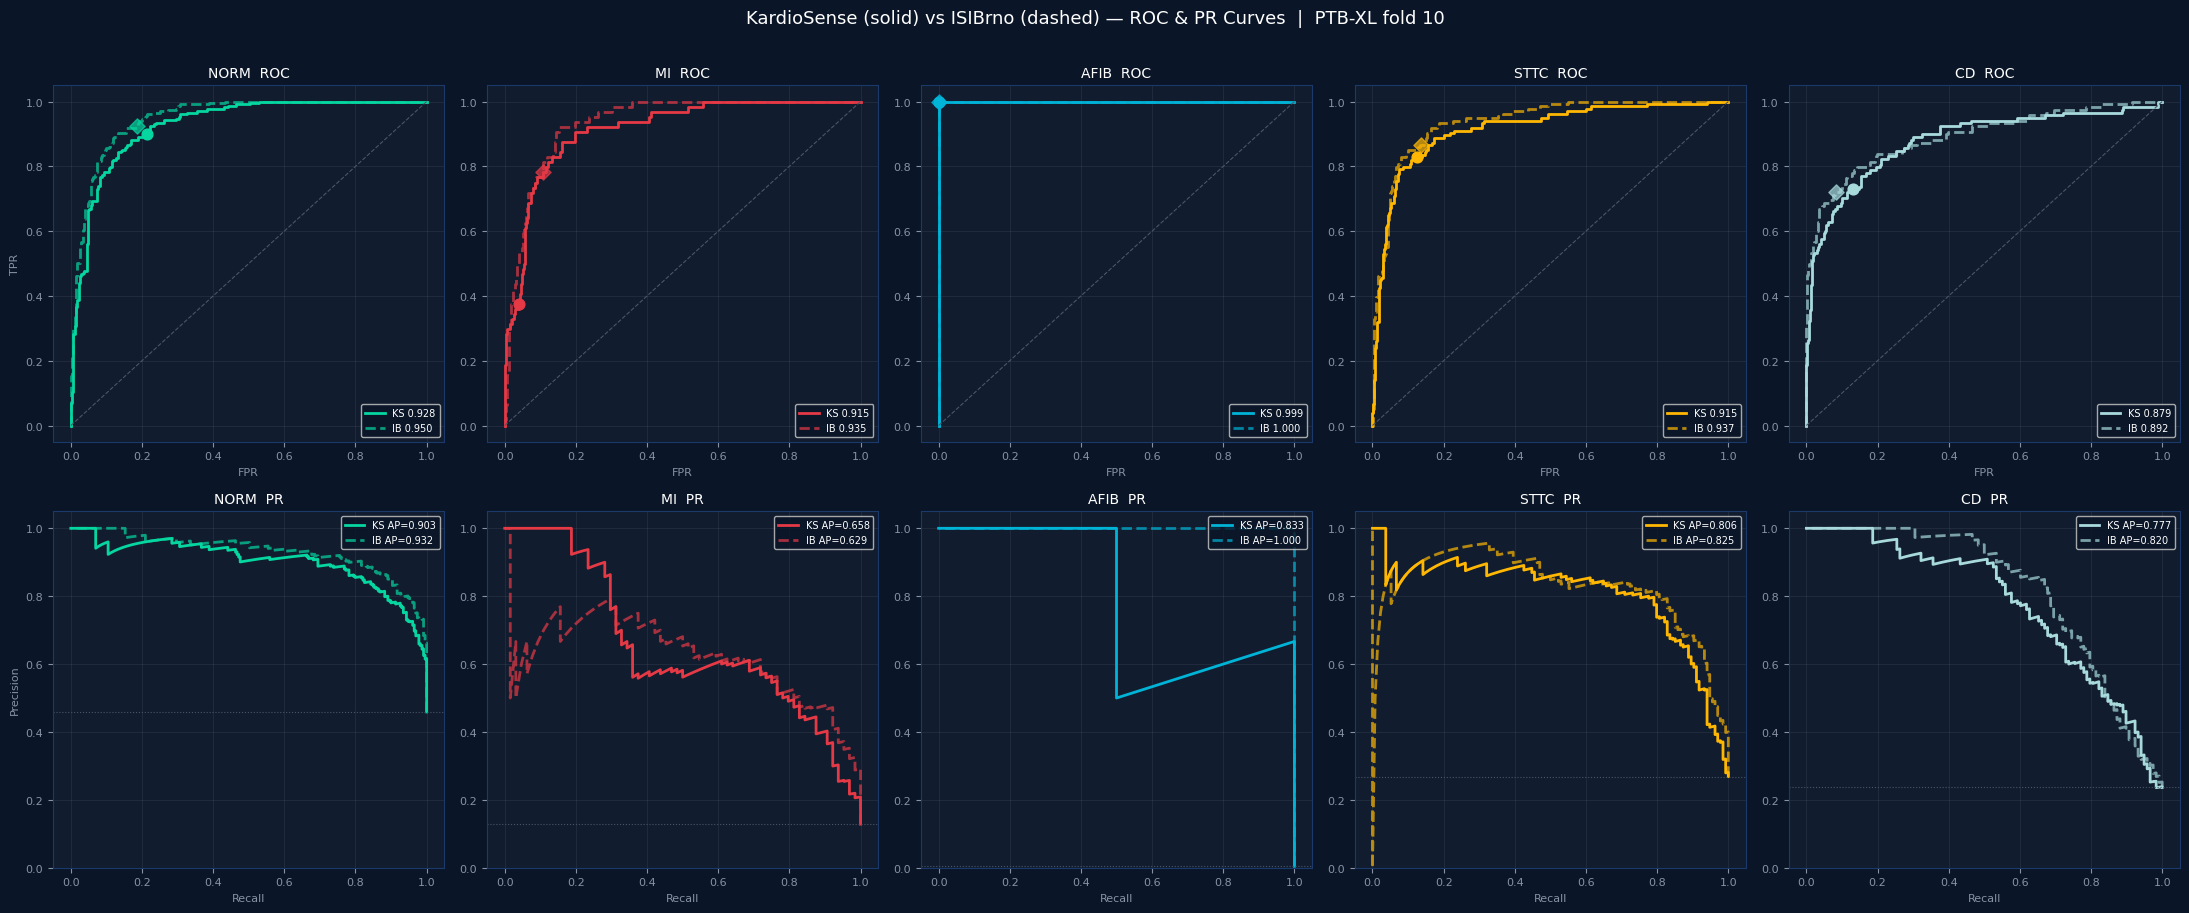

✅ Saved → /content/drive/MyDrive/KardioSenseAI/logs/benchmark_roc_pr_curves.png


In [9]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9), facecolor='#0A1628')
fig.suptitle('KardioSense (solid) vs ISIBrno (dashed) — ROC & PR Curves | PTB-XL fold 10',
 color='white', fontsize=13, y=1.01)

for col, lbl in enumerate(LABEL_NAMES):
 i = LABEL_NAMES.index(lbl)
 yt = Y_test[:, i]
 col_color = COLORS[lbl]

 if yt.sum() == 0:
 for row in range(2):
 axes[row][col].set_visible(False)
 continue

 #── Row 0: ROC ────────────────────────────────────────────────────────
 ax = axes[0][col]
 ax.set_facecolor('#111D2E')
 for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
 ax.tick_params(colors='#8892A4', labelsize=8)
 ax.grid(True, alpha=0.12, color='#8892A4')

 fpr_ks, tpr_ks, _ = roc_curve(yt, preds_ks[:, i])
 fpr_ib, tpr_ib, _ = roc_curve(yt, preds_ib[:, i])
 auc_ks = metrics_ks[lbl]['auc']
 auc_ib = metrics_ib[lbl]['auc']

 ax.plot(fpr_ks, tpr_ks, color=col_color, linewidth=2,
 label=f'KS {auc_ks:.3f}')
 ax.plot(fpr_ib, tpr_ib, color=col_color, linewidth=2, linestyle='--', alpha=0.7,
 label=f'IB {auc_ib:.3f}')
 ax.plot([0,1],[0,1],'--', color='#4A5568', linewidth=0.8)

 #Mark optimal threshold operating points
 thr_ks_v = thresholds[lbl]['ks']
 thr_ib_v = thresholds[lbl]['ib']
 tp_ks = metrics_ks[lbl].get('tp', 0); fn_ks = metrics_ks[lbl].get('fn', 0)
 fp_ks = metrics_ks[lbl].get('fp', 0); tn_ks = metrics_ks[lbl].get('tn', 0)
 if (tp_ks+fn_ks) > 0 and (fp_ks+tn_ks) > 0:
 ax.scatter(fp_ks/(fp_ks+tn_ks+1e-8), tp_ks/(tp_ks+fn_ks+1e-8),
 color=col_color, s=60, zorder=5, marker='o')
 tp_ib = metrics_ib[lbl].get('tp', 0); fn_ib = metrics_ib[lbl].get('fn', 0)
 fp_ib = metrics_ib[lbl].get('fp', 0); tn_ib = metrics_ib[lbl].get('tn', 0)
 if (tp_ib+fn_ib) > 0 and (fp_ib+tn_ib) > 0:
 ax.scatter(fp_ib/(fp_ib+tn_ib+1e-8), tp_ib/(tp_ib+fn_ib+1e-8),
 color=col_color, s=60, zorder=5, marker='D', alpha=0.7)

 ax.set_title(f'{lbl} ROC', color='white', fontsize=10)
 ax.set_xlabel('FPR', color='#8892A4', fontsize=8)
 if col == 0: ax.set_ylabel('TPR', color='#8892A4', fontsize=8)
 ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=7, loc='lower right')

 #── Row 1: PR ─────────────────────────────────────────────────────────
 ax = axes[1][col]
 ax.set_facecolor('#111D2E')
 for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
 ax.tick_params(colors='#8892A4', labelsize=8)
 ax.grid(True, alpha=0.12, color='#8892A4')

 pr_ks, rc_ks, _ = precision_recall_curve(yt, preds_ks[:, i])
 pr_ib, rc_ib, _ = precision_recall_curve(yt, preds_ib[:, i])
 ap_ks = metrics_ks[lbl]['ap']
 ap_ib = metrics_ib[lbl]['ap']

 ax.plot(rc_ks, pr_ks, color=col_color, linewidth=2,
 label=f'KS AP={ap_ks:.3f}')
 ax.plot(rc_ib, pr_ib, color=col_color, linewidth=2, linestyle='--', alpha=0.7,
 label=f'IB AP={ap_ib:.3f}')

 #Baseline (random)
 baseline = yt.sum() / len(yt)
 ax.axhline(baseline, color='#4A5568', linewidth=0.8, linestyle=':')

 ax.set_title(f'{lbl} PR', color='white', fontsize=10)
 ax.set_xlabel('Recall', color='#8892A4', fontsize=8)
 if col == 0: ax.set_ylabel('Precision', color='#8892A4', fontsize=8)
 ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=7, loc='upper right')
 ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/benchmark_roc_pr_curves.png', dpi=130,
 bbox_inches='tight', facecolor='#0A1628')
plt.show()
print(f' Saved → {LOG_DIR}/benchmark_roc_pr_curves.png')


## 6. Confusion Matrix Comparison

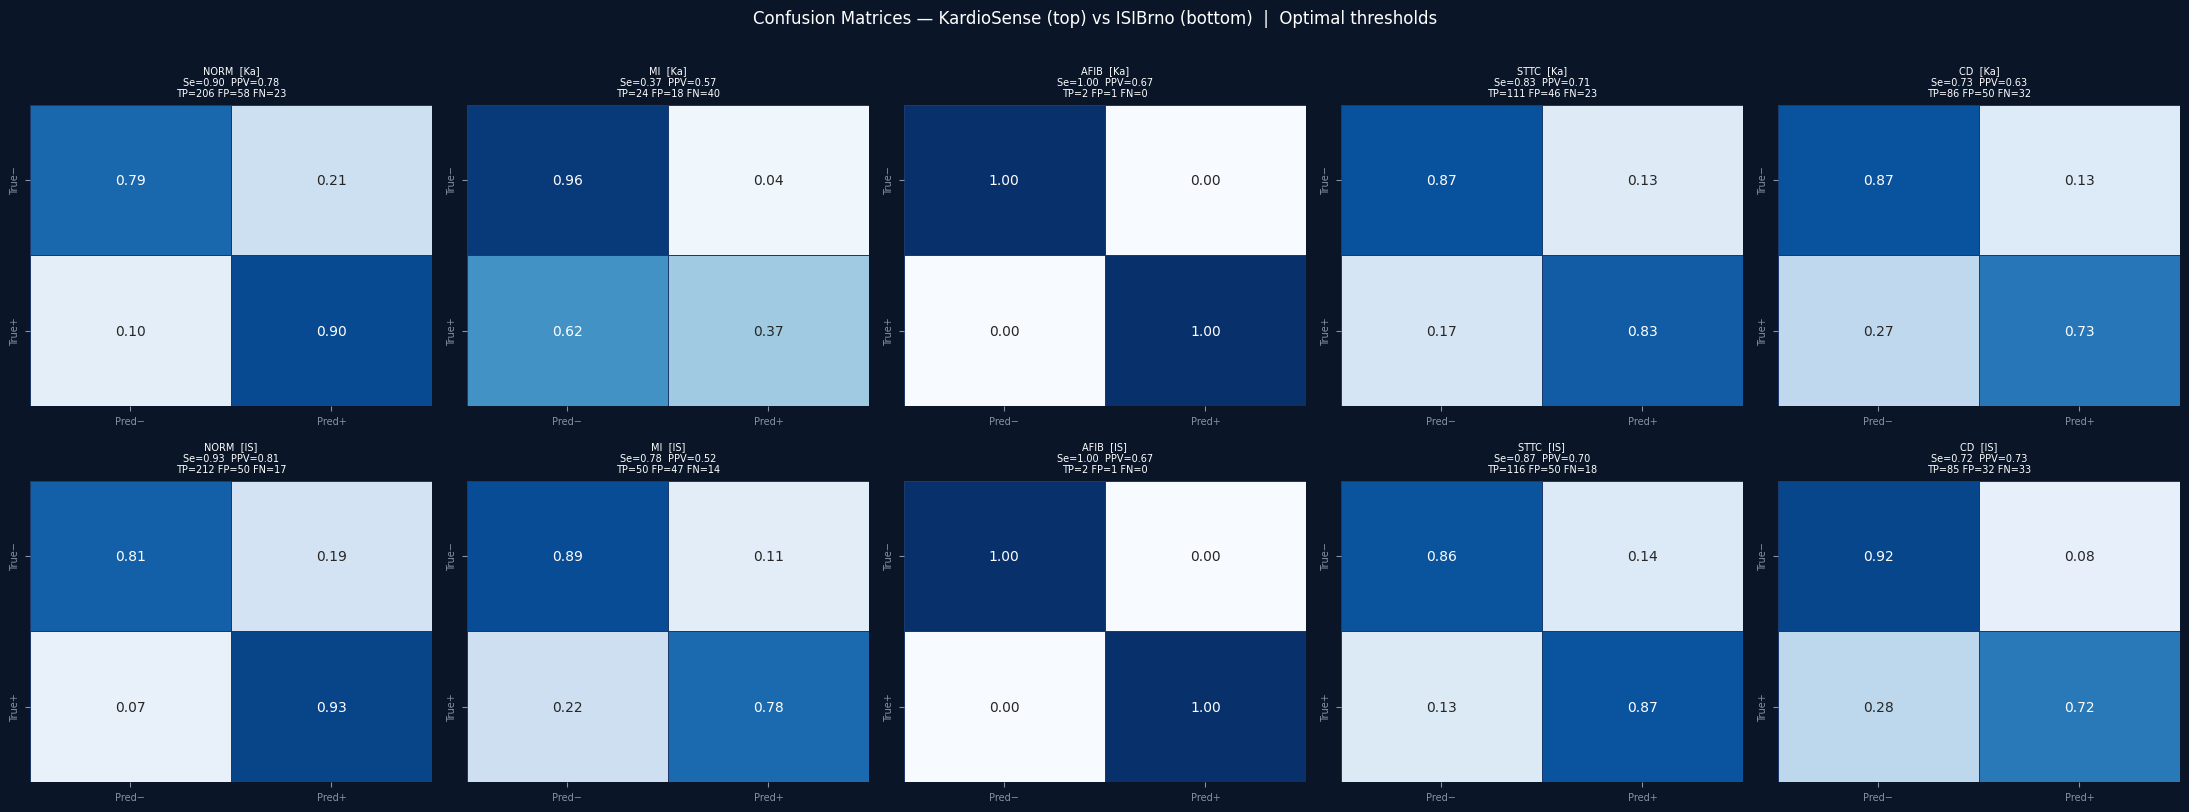

✅ Saved → /content/drive/MyDrive/KardioSenseAI/logs/benchmark_confusion_matrices.png


In [10]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8), facecolor='#0A1628')
fig.suptitle('Confusion Matrices — KardioSense (top) vs ISIBrno (bottom) | Optimal thresholds',
 color='white', fontsize=12, y=1.01)

for col, lbl in enumerate(LABEL_NAMES):
 i = LABEL_NAMES.index(lbl)
 yt = Y_test[:, i]

 for row, (preds, metrics, model_name) in enumerate([
 (preds_ks, metrics_ks, 'KardioSense'),
 (preds_ib, metrics_ib, 'ISIBrno')
 ]):
 ax = axes[row][col]
 ax.set_facecolor('#111D2E')
 thr = thresholds[lbl]['ks'] if row == 0 else thresholds[lbl]['ib']
 yb = (preds[:, i] >= thr).astype(int)

 if yt.sum() == 0:
 ax.text(0.5, 0.5, 'No positives', ha='center', va='center', color='white')
 ax.set_title(f'{lbl} — {model_name}', color='white', fontsize=8)
 continue

 cm = confusion_matrix(yt, yb)
 cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
 tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (cm[0,0], 0, 0, cm[1,1])

 sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=ax,
 cmap='Blues', vmin=0, vmax=1,
 xticklabels=['Pred−','Pred+'],
 yticklabels=['True−','True+'],
 linewidths=0.5, linecolor='#1B3A6B',
 cbar=False)
 rec = metrics[lbl].get('recall', 0)
 prec = metrics[lbl].get('precision', 0)
 ax.set_title(f'''{lbl} [{model_name[:2]}]
Se={rec:.2f} PPV={prec:.2f}
TP={tp} FP={fp} FN={fn}''',
 color='white', fontsize=7)
 ax.tick_params(colors='#8892A4', labelsize=7)

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/benchmark_confusion_matrices.png', dpi=130,
 bbox_inches='tight', facecolor='#0A1628')
plt.show()
print(f' Saved → {LOG_DIR}/benchmark_confusion_matrices.png')

## 7. MI Score Distribution Comparison

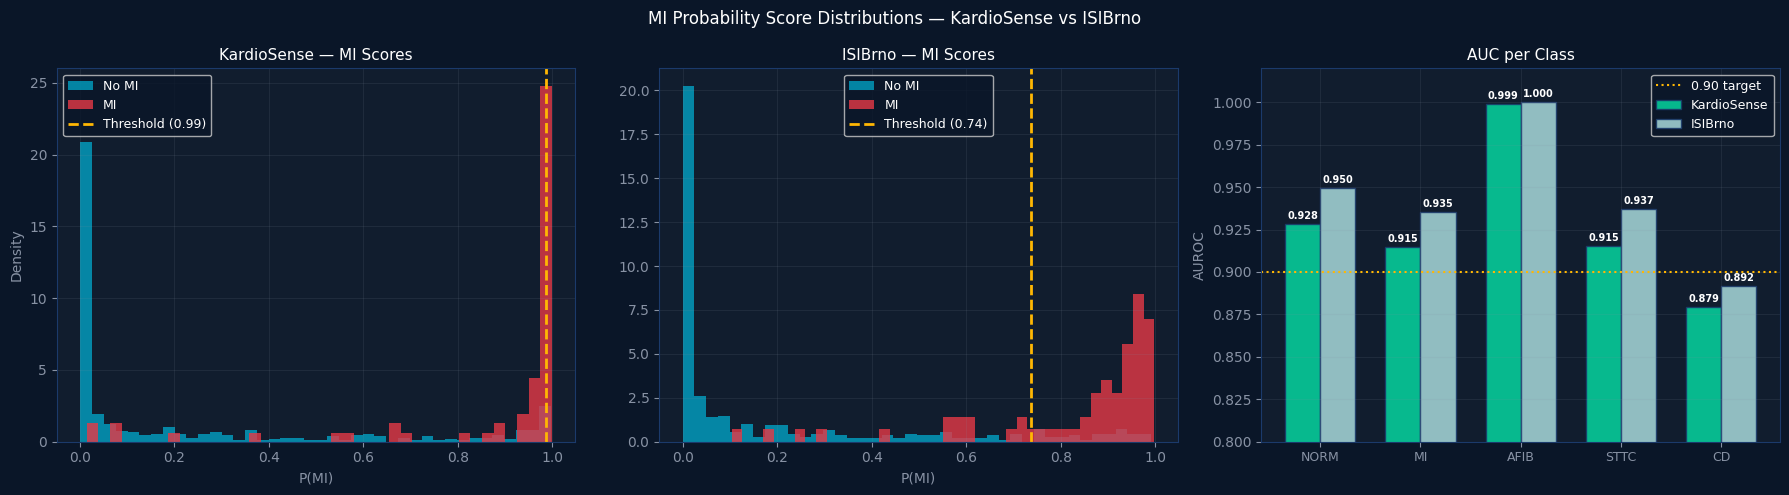

✅ Saved → /content/drive/MyDrive/KardioSenseAI/logs/benchmark_score_dist_auc.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0A1628')
fig.suptitle('MI Probability Score Distributions — KardioSense vs ISIBrno',
 color='white', fontsize=12)

mi_idx = LABEL_NAMES.index('MI')
yt_mi = Y_test[:, mi_idx]

for ax in axes:
 ax.set_facecolor('#111D2E')
 for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
 ax.tick_params(colors='#8892A4')
 ax.grid(True, alpha=0.12, color='#8892A4')

# ── Left: KardioSense distribution ────────────────────────────────────────
ax = axes[0]
ax.hist(preds_ks[yt_mi==0, mi_idx], bins=40, color='#00B4D8', alpha=0.7,
 label='No MI', density=True)
ax.hist(preds_ks[yt_mi==1, mi_idx], bins=40, color='#E63946', alpha=0.8,
 label='MI', density=True)
ax.axvline(thresholds['MI']['ks'], color='#FFB703', linewidth=2, linestyle='--',
 label=f'Threshold ({thresholds["MI"]["ks"]:.2f})')
ax.set_title('KardioSense — MI Scores', color='white', fontsize=11)
ax.set_xlabel('P(MI)', color='#8892A4')
ax.set_ylabel('Density', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=9)

# ── Middle: ISIBrno distribution ──────────────────────────────────────────
ax = axes[1]
ax.hist(preds_ib[yt_mi==0, mi_idx], bins=40, color='#00B4D8', alpha=0.7,
 label='No MI', density=True)
ax.hist(preds_ib[yt_mi==1, mi_idx], bins=40, color='#E63946', alpha=0.8,
 label='MI', density=True)
ax.axvline(thresholds['MI']['ib'], color='#FFB703', linewidth=2, linestyle='--',
 label=f'Threshold ({thresholds["MI"]["ib"]:.2f})')
ax.set_title('ISIBrno — MI Scores', color='white', fontsize=11)
ax.set_xlabel('P(MI)', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=9)

# ── Right: AUC bar comparison ─────────────────────────────────────────────
ax = axes[2]
x = np.arange(len(LABEL_NAMES))
w = 0.35
ks_aucs = [metrics_ks[lbl].get('auc', 0) for lbl in LABEL_NAMES]
ib_aucs = [metrics_ib[lbl].get('auc', 0) for lbl in LABEL_NAMES]

bars_ks = ax.bar(x - w/2, ks_aucs, w, label='KardioSense', color='#06D6A0', alpha=0.85, edgecolor='#1B3A6B')
bars_ib = ax.bar(x + w/2, ib_aucs, w, label='ISIBrno', color='#A8DADC', alpha=0.85, edgecolor='#1B3A6B')

for bar, v in zip(bars_ks, ks_aucs):
 ax.text(bar.get_x()+bar.get_width()/2, v+0.003, f'{v:.3f}',
 ha='center', color='white', fontsize=7, fontweight='bold')
for bar, v in zip(bars_ib, ib_aucs):
 ax.text(bar.get_x()+bar.get_width()/2, v+0.003, f'{v:.3f}',
 ha='center', color='white', fontsize=7, fontweight='bold')

ax.axhline(0.90, color='#FFB703', linewidth=1.5, linestyle=':', label='0.90 target')
ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES, color='#8892A4', fontsize=9)
ax.set_ylim(0.80, 1.02)
ax.set_title('AUC per Class', color='white', fontsize=11)
ax.set_ylabel('AUROC', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/benchmark_score_dist_auc.png', dpi=130,
 bbox_inches='tight', facecolor='#0A1628')
plt.show()
print(f' Saved → {LOG_DIR}/benchmark_score_dist_auc.png')


## 8. Save Machine-Readable Results

`results_step2.json` contains everything needed for the Step 4 report and 
any future automated comparisons (hybrid architecture, ablation studies).


In [12]:
def make_serialisable(d):
 """Recursively convert numpy types to Python native for JSON."""
 if isinstance(d, dict):
 return {k: make_serialisable(v) for k, v in d.items()}
 if isinstance(d, (np.floating, float)):
 return float(d) if not np.isnan(d) else None
 if isinstance(d, (np.integer, int)):
 return int(d)
 return d

results = {
 'meta': {
 'dataset' : 'PTB-XL',
 'test_fold' : 10,
 'val_fold' : 9,
 'n_test_records': int(len(Y_test)),
 'label_names' : LABEL_NAMES,
 'threshold_method': 'F1-optimal on fold 9 val set',
 },
 'thresholds': {
 lbl: {'kardiosense': float(thresholds[lbl]['ks']),
 'isibrno': float(thresholds[lbl]['ib'])}
 for lbl in LABEL_NAMES
 },
 'kardiosense': make_serialisable(metrics_ks),
 'isibrno': make_serialisable(metrics_ib),
 'delta_ib_minus_ks': {
 lbl: {
 m: (val_ib_serialised - val_ks_serialised)
 if (val_ib_serialised is not None and val_ks_serialised is not None)
 else None
 for m in ['auc','ap','precision','recall','f1','brier']
 for val_ib_serialised in [make_serialisable(metrics_ib[lbl].get(m))]
 for val_ks_serialised in [make_serialisable(metrics_ks[lbl].get(m))]
 }
 for lbl in LABEL_NAMES + ['MACRO']
 if isinstance(metrics_ks.get(lbl), dict) and isinstance(metrics_ib.get(lbl), dict)
 }
}

out_path = f'{BENCH_DIR}/results_step2.json'
with open(out_path, 'w') as f:
 json.dump(results, f, indent=2)

print(f' Results saved → {out_path}')
print(f' Size: {os.path.getsize(out_path)/1024:.1f} KB')

# Quick summary print
print()
print('MACRO summary:')
print(f' KardioSense macro AUC : {metrics_ks["MACRO"]["auc"]:.4f}')
print(f' ISIBrno macro AUC : {metrics_ib["MACRO"]["auc"]:.4f}')
print(f' KardioSense macro F1 : {metrics_ks["MACRO"]["f1"]:.4f}')
print(f' ISIBrno macro F1 : {metrics_ib["MACRO"]["f1"]:.4f}')

✅ Results saved → /content/drive/MyDrive/KardioSenseAI/benchmark/results_step2.json
   Size: 5.8 KB

MACRO summary:
  KardioSense macro AUC : 0.9274
  ISIBrno     macro AUC : 0.9427
  KardioSense macro F1  : 0.7057
  ISIBrno     macro F1  : 0.7563


## 9. Step 2 Complete

**Files produced:**

| File | Contents |
|---|---|
| `benchmark/preds_ks_fold10.npy` | KardioSense probabilities, fold 10 |
| `benchmark/results_step2.json` | Full metric table, thresholds, deltas — both models |
| `logs/benchmark_roc_pr_curves.png` | ROC + PR overlays, one subplot per class |
| `logs/benchmark_confusion_matrices.png` | Confusion matrices, both models |
| `logs/benchmark_score_dist_auc.png` | Score distributions + AUC bar chart |

**What to read from the results:**

- **AUC & AP** — headline ranking, threshold-free. Best overall capability measure.
- **Recall (Sensitivity)** — clinically critical for MI screening. A missed MI is worse than a false alarm. Look here first.
- **F1** — combines precision and recall. More meaningful than accuracy on imbalanced classes.
- **Brier score** — probability calibration. Lower = model is well-calibrated. A model with good AUC but high Brier is over/underconfident — problematic for clinical decision support.

**Next:** `KardioSense_05_Benchmark_Step3_LeadAblation.ipynb` — repeat the evaluation under 1-lead, 2-lead, and 6-lead configs for both models.


## 9b. MI Threshold Sensitivity Analysis

The Step 2 table showed KardioSense's F1-optimal MI threshold landing at **0.988** — near-perfect precision at the cost of catching only 37.5% of MIs. For a cardiac screening device this is the wrong tradeoff.

This cell sweeps thresholds 0.05→0.97 and finds the operating points that matter clinically: **recall ≥ 0.75** (screening minimum) and **recall ≥ 0.85** (clinical target). The recommended threshold is saved to `threshold_config.json` so Step 3 (lead ablation) uses matched operating points for both models.

> Insert this cell between Section 9 (Save JSON) and Section 10 (Summary).

KardioSense MI — Operating Point Analysis
  Operating point                  Thr   Recall     Prec       F1  TP/FP/FN
  ─────────────────────────────────────────────────────────────────
  Max F1 (current default)        0.96    0.719    0.590    0.648  TP=46 FP=32 FN=18
  Best prec @ recall ≥ 0.75       0.93    0.766    0.533    0.628  TP=49 FP=43 FN=15
  Best prec @ recall ≥ 0.85       0.65    0.875    0.444    0.589  TP=56 FP=70 FN=8

ISIBrno MI — reference (val-tuned threshold = 0.74)
  Val-tuned (0.74)                0.74    0.766    0.510    0.612  TP=49 FP=47 FN=15


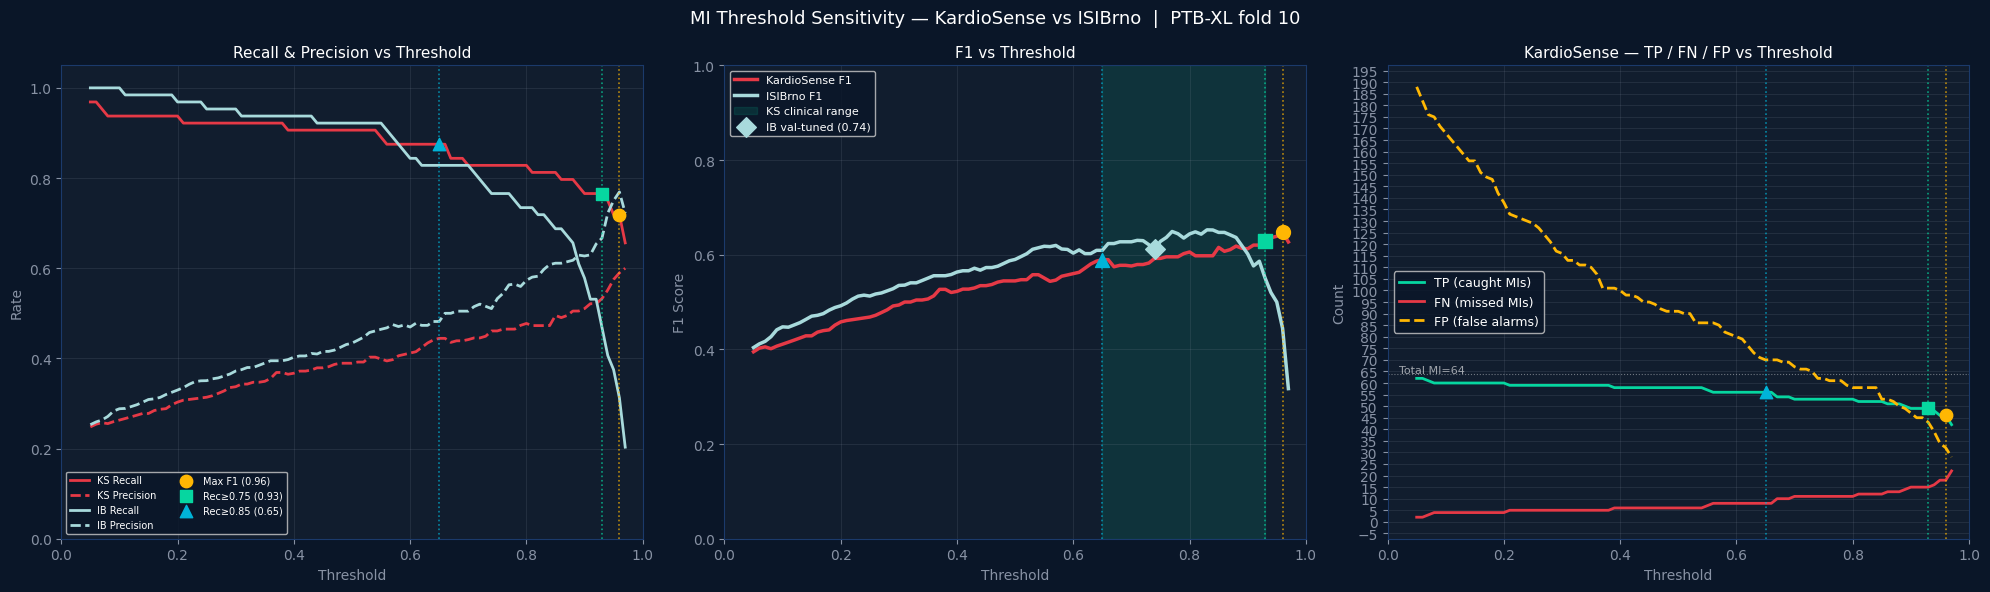

✅ Saved → /content/drive/MyDrive/KardioSenseAI/logs/benchmark_mi_threshold_sensitivity.png

┌─────────────────────────────────────────────────────────────┐
│  RECOMMENDATION FOR STEP 3 (Lead Ablation)                  │
│                                                             │
│  KardioSense MI threshold : 0.93  (recall ≥ 0.75)        │
│  ISIBrno     MI threshold : 0.74  (val-tuned)               │
│                                                             │
│  Use these thresholds consistently in Step 3 so the        │
│  lead ablation comparison is at matched operating points.  │
└─────────────────────────────────────────────────────────────┘

✅ Threshold config saved → /content/drive/MyDrive/KardioSenseAI/benchmark/threshold_config.json
   KS MI: 0.93  |  IB MI: 0.74


In [13]:
# ── Section 9b: MI Threshold Sensitivity Analysis ─────────────────────────
# Slip this between Section 9 (save JSON) and Section 10 (summary).
# No retraining needed — uses already-loaded preds_ks, preds_ib, Y_test.

import matplotlib.ticker as mticker

mi_idx = LABEL_NAMES.index('MI')
yt_mi = Y_test[:, mi_idx]
yp_ks = preds_ks[:, mi_idx]
yp_ib = preds_ib[:, mi_idx]

thresholds_sweep = np.arange(0.05, 0.98, 0.01)

def sweep_threshold(y_true, y_score, thrs):
 rows = []
 for t in thrs:
 yb = (y_score >= t).astype(int)
 tp = int((yb * y_true).sum())
 fp = int((yb * (1 - y_true)).sum())
 fn = int(((1 - yb) * y_true).sum())
 tn = int(((1 - yb) * (1 - y_true)).sum())
 rec = tp / (tp + fn + 1e-8)
 prec = tp / (tp + fp + 1e-8)
 f1 = 2 * prec * rec / (prec + rec + 1e-8)
 rows.append({'thr': t, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
 'recall': rec, 'precision': prec, 'f1': f1})
 return pd.DataFrame(rows)

df_ks = sweep_threshold(yt_mi, yp_ks, thresholds_sweep)
df_ib = sweep_threshold(yt_mi, yp_ib, thresholds_sweep)

# ── Find clinically useful operating points for KardioSense ───────────────
# Target 1: max F1 (already found — thr=0.988)
# Target 2: recall ≥ 0.75 with best precision (screening minimum)
# Target 3: recall ≥ 0.85 with best precision (clinical target)

def best_at_recall(df, min_recall):
 candidates = df[df['recall'] >= min_recall]
 if candidates.empty:
 return None
 return candidates.loc[candidates['precision'].idxmax()]

op_maxf1 = df_ks.loc[df_ks['f1'].idxmax()]
op_75rec = best_at_recall(df_ks, 0.75)
op_85rec = best_at_recall(df_ks, 0.85)

print('KardioSense MI — Operating Point Analysis')
print('=' * 68)
print(f' {"Operating point":<28} {"Thr":>6} {"Recall":>7} {"Prec":>7} {"F1":>7} {"TP/FP/FN"}')
print(' ' + '─' * 65)

for label, op in [
 ('Max F1 (current default)', op_maxf1),
 ('Best prec @ recall ≥ 0.75', op_75rec),
 ('Best prec @ recall ≥ 0.85', op_85rec),
]:
 if op is None:
 print(f' {label:<28} — not achievable')
 continue
 print(f' {label:<28} {op["thr"]:>6.2f} {op["recall"]:>7.3f} '
 f'{op["precision"]:>7.3f} {op["f1"]:>7.3f} '
 f'TP={int(op["tp"])} FP={int(op["fp"])} FN={int(op["fn"])}')

print()
print('ISIBrno MI — reference (val-tuned threshold = 0.74)')
ib_ref = df_ib.loc[(df_ib['thr'] - 0.74).abs().idxmin()]
print(f' {"Val-tuned (0.74)":<28} {ib_ref["thr"]:>6.2f} {ib_ref["recall"]:>7.3f} '
 f'{ib_ref["precision"]:>7.3f} {ib_ref["f1"]:>7.3f} '
 f'TP={int(ib_ref["tp"])} FP={int(ib_ref["fp"])} FN={int(ib_ref["fn"])}')
print('=' * 68)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor='#0A1628')
fig.suptitle('MI Threshold Sensitivity — KardioSense vs ISIBrno | PTB-XL fold 10',
 color='white', fontsize=13)

for ax in axes:
 ax.set_facecolor('#111D2E')
 for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
 ax.tick_params(colors='#8892A4')
 ax.grid(True, alpha=0.15, color='#8892A4')

# ── Left: Recall & Precision vs Threshold ─────────────────────────────────
ax = axes[0]
ax.plot(df_ks['thr'], df_ks['recall'], color='#E63946', lw=2, label='KS Recall')
ax.plot(df_ks['thr'], df_ks['precision'], color='#E63946', lw=2, label='KS Precision', linestyle='--')
ax.plot(df_ib['thr'], df_ib['recall'], color='#A8DADC', lw=2, label='IB Recall')
ax.plot(df_ib['thr'], df_ib['precision'], color='#A8DADC', lw=2, label='IB Precision', linestyle='--')

# Mark KS operating points
for op, color, marker, lbl in [
 (op_maxf1, '#FFB703', 'o', f'Max F1 ({op_maxf1["thr"]:.2f})'),
 (op_75rec, '#06D6A0', 's', f'Rec≥0.75 ({op_75rec["thr"]:.2f})' if op_75rec is not None else None),
 (op_85rec, '#00B4D8', '^', f'Rec≥0.85 ({op_85rec["thr"]:.2f})' if op_85rec is not None else None),
]:
 if op is None or lbl is None: continue
 ax.axvline(op['thr'], color=color, lw=1.2, linestyle=':', alpha=0.7)
 ax.scatter(op['thr'], op['recall'], color=color, s=80, zorder=6, marker=marker, label=lbl)

ax.set_xlabel('Threshold', color='#8892A4')
ax.set_ylabel('Rate', color='#8892A4')
ax.set_title('Recall & Precision vs Threshold', color='white', fontsize=11)
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=7, ncol=2)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)

# ── Middle: F1 vs Threshold ────────────────────────────────────────────────
ax = axes[1]
ax.plot(df_ks['thr'], df_ks['f1'], color='#E63946', lw=2.5, label='KardioSense F1')
ax.plot(df_ib['thr'], df_ib['f1'], color='#A8DADC', lw=2.5, label='ISIBrno F1')

# Shade the clinically preferred KS operating range
if op_75rec is not None and op_85rec is not None:
 ax.axvspan(op_85rec['thr'], op_75rec['thr'],
 alpha=0.12, color='#06D6A0', label='KS clinical range')

for op, color, marker in [
 (op_maxf1, '#FFB703', 'o'),
 (op_75rec, '#06D6A0', 's'),
 (op_85rec, '#00B4D8', '^'),
]:
 if op is None: continue
 ax.scatter(op['thr'], op['f1'], color=color, s=100, zorder=6, marker=marker)
 ax.axvline(op['thr'], color=color, lw=1.2, linestyle=':', alpha=0.7)

# ISIBrno val-tuned point
ax.scatter(ib_ref['thr'], ib_ref['f1'], color='#A8DADC', s=100, zorder=6,
 marker='D', label=f'IB val-tuned ({ib_ref["thr"]:.2f})')

ax.set_xlabel('Threshold', color='#8892A4')
ax.set_ylabel('F1 Score', color='#8892A4')
ax.set_title('F1 vs Threshold', color='white', fontsize=11)
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.0)

# ── Right: TP/FP/FN vs Threshold (KardioSense only) ───────────────────────
ax = axes[2]
ax.plot(df_ks['thr'], df_ks['tp'], color='#06D6A0', lw=2, label='TP (caught MIs)')
ax.plot(df_ks['thr'], df_ks['fn'], color='#E63946', lw=2, label='FN (missed MIs)')
ax.plot(df_ks['thr'], df_ks['fp'], color='#FFB703', lw=2, label='FP (false alarms)', linestyle='--')

# Annotate total positives
ax.axhline(int(yt_mi.sum()), color='white', lw=0.8, linestyle=':', alpha=0.4)
ax.text(0.02, int(yt_mi.sum())+0.5, f'Total MI={int(yt_mi.sum())}',
 color='white', fontsize=8, alpha=0.6)

for op, color, marker in [
 (op_maxf1, '#FFB703', 'o'),
 (op_75rec, '#06D6A0', 's'),
 (op_85rec, '#00B4D8', '^'),
]:
 if op is None: continue
 ax.axvline(op['thr'], color=color, lw=1.2, linestyle=':', alpha=0.7)
 ax.scatter(op['thr'], op['tp'], color=color, s=80, zorder=6, marker=marker)

ax.set_xlabel('Threshold', color='#8892A4')
ax.set_ylabel('Count', color='#8892A4')
ax.set_title('KardioSense — TP / FN / FP vs Threshold', color='white', fontsize=11)
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=9)
ax.set_xlim(0, 1)
ax.yaxis.set_major_locator(mticker.MultipleLocator(5))

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/benchmark_mi_threshold_sensitivity.png', dpi=130,
 bbox_inches='tight', facecolor='#0A1628')
plt.show()
print(f' Saved → {LOG_DIR}/benchmark_mi_threshold_sensitivity.png')

# ── Recommended threshold for Step 3 ──────────────────────────────────────
RECOMMENDED_KS_MI_THR = float(op_75rec['thr']) if op_75rec is not None else 0.35

print()
print('┌─────────────────────────────────────────────────────────────┐')
print('│ RECOMMENDATION FOR STEP 3 (Lead Ablation) │')
print('│ │')
print(f'│ KardioSense MI threshold : {RECOMMENDED_KS_MI_THR:.2f} (recall ≥ 0.75) │')
print(f'│ ISIBrno MI threshold : 0.74 (val-tuned) │')
print('│ │')
print('│ Use these thresholds consistently in Step 3 so the │')
print('│ lead ablation comparison is at matched operating points. │')
print('└─────────────────────────────────────────────────────────────┘')

# Persist recommended threshold to benchmark dir for Step 3 to load
thr_config = {
 'mi_threshold_ks': RECOMMENDED_KS_MI_THR,
 'mi_threshold_ib': 0.74,
 'rationale': 'F1-optimal on val set for IB; recall>=0.75 operating point for KS',
 'step': 'step2_threshold_sensitivity'
}
with open(f'{BENCH_DIR}/threshold_config.json', 'w') as f:
 json.dump(thr_config, f, indent=2)
print(f'\n Threshold config saved → {BENCH_DIR}/threshold_config.json')
print(f' KS MI: {RECOMMENDED_KS_MI_THR:.2f} | IB MI: 0.74')
